<a href="https://colab.research.google.com/github/devaki-turimella/FUTURE_ML_03/blob/main/Resume_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading dataset... this may take few seconds (file is big)
Total resumes in dataset: 3446
Job categories available: ['HR' nan ' Process Improvements' 'DESIGNER' ' Word'
 'INFORMATION-TECHNOLOGY' ' Oracle database' 'TEACHER' 'ADVOCATE'
 ' promotions' ' adding beneficiaries'
 ' posting and reconciling large- volume batch summary transactions'
 ' Business Development' 'BUSINESS-DEVELOPMENT'
 ' worked closely with end customer and subcontractors (Solectron'
 'HEALTHCARE'
 ' </span> <span class=""jobdates"" format=""%m/%Y"" id=""2889ba25-598f-4cae-9f07-3400bd2e9b42JSTD2""> 09/2018</span> <span dependency=""JSTD+EDDT"">  to </span> <span class=""jobdates"" format=""%m/%Y"" id=""2889ba25-598f-4cae-9f07-3400bd2e9b42EDDT2""> 07/2020</span> <br/> </span> <span class=""paddedline"" itemscope="""" itemtype=""https://schema.org/postalAddress""> <span class=""companyname"" id=""2889ba25-598f-4cae-9f07-3400bd2e9b42COMP2"" itemprop=""name""> Company Name</span> <span>  – </span> <span class=""joblocat

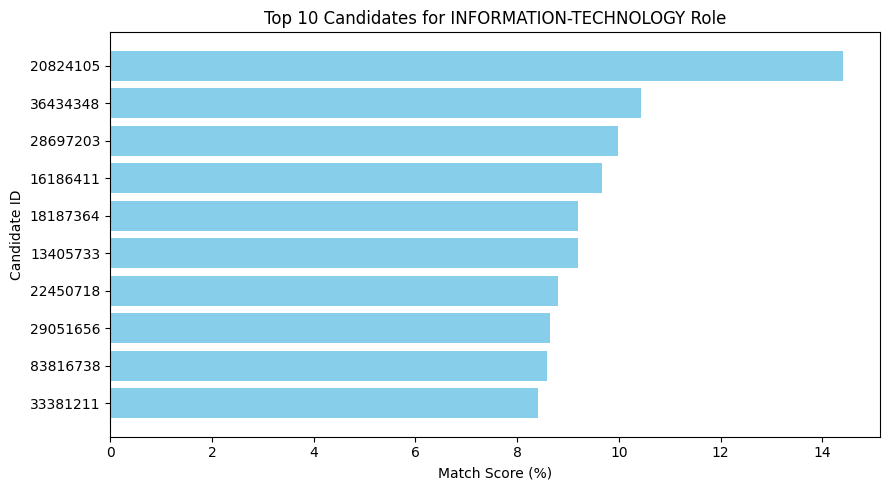

In [9]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 50)
STOPWORDS = set("""a an the is are was were be been being am i you he she it we they this that these those of in on at to for with from by as and or but
not no nor so if then than too very can will would should could may might must shall do does did have has had my your his her its our their what which who
whom when where why how all any both each few more most other some such only own same just also into about above below up down out over under again further
once here there all """.split())


def clean_resume_text(text):
    """basic cleaning of resume / job description text"""
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return " ".join(words)


SKILL_LIST = [
    "python", "java", "c++", "sql", "excel", "powerpoint",
    "machine learning", "deep learning", "data analysis", "data science",
    "nlp", "tensorflow", "pytorch", "html", "css", "javascript", "react",
    "project management", "accounting", "auditing", "tally", "budgeting",
    "customer service", "sales", "marketing", "negotiation", "leadership",
    "communication", "teamwork", "photoshop", "illustrator", "autocad",
    "recruiting", "hr", "payroll", "scheduling", "cooking", "baking",
    "menu planning", "food safety", "first aid", "fitness training",
    "social media", "seo", "content writing", "public speaking",
    "logistics", "supply chain", "inventory management", "networking",
    "cloud computing", "aws", "azure", "linux", "database management",
    "agile", "scrum", "testing", "debugging", "problem solving",
]


def extract_skills(clean_text):
    """check which skills from SKILL_LIST are present in the text"""
    found_skills = []
    for skill in SKILL_LIST:
        if skill in clean_text:
            found_skills.append(skill)
    return found_skills


def skill_gap(resume_skills, jd_skills):
    """skills required in job but missing from resume"""
    missing = [s for s in jd_skills if s not in resume_skills]
    return missing

print("Loading dataset... this may take few seconds (file is big)")
df = pd.read_csv("/content/drive/MyDrive/dev/Resume.csv", engine='python', on_bad_lines='skip')
df = df[["ID", "Resume_str", "Category"]]  # no need Resume_html column

print("Total resumes in dataset:", len(df))
print("Job categories available:", df["Category"].unique())

TARGET_CATEGORY = "INFORMATION-TECHNOLOGY"

if TARGET_CATEGORY in df["Category"].unique():
    df = df[df["Category"] == TARGET_CATEGORY].reset_index(drop=True)
    print(f"\nFiltered to category: {TARGET_CATEGORY}, total resumes now: {len(df)}")
else:
    print("\nTarget category not found, using full dataset")

print("\nCleaning resume text and extracting skills...")
df["clean_resume"] = df["Resume_str"].apply(clean_resume_text)
df["resume_skills"] = df["clean_resume"].apply(extract_skills)

job_description = """
We are looking for an IT professional with strong skills in Python,
SQL, machine learning and data analysis. The candidate should know
cloud computing (AWS/Azure), have good communication and problem
solving skills, and should be comfortable with agile and scrum way
of working.
Knowledge of networking and database management is a
plus point.
"""

clean_jd = clean_resume_text(job_description)
jd_skills = extract_skills(clean_jd)

print("\n--- JOB DESCRIPTION SKILLS REQUIRED ---")
print(jd_skills)

print("\nCalculating similarity score for every resume...")

corpus = df["clean_resume"].tolist()
corpus.append(clean_jd)     # putting jd as last item of the list

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(corpus)

jd_vector = tfidf_matrix[-1]            # last row is the jd
resume_vectors = tfidf_matrix[:-1]      # all rows except last are resumes

scores = cosine_similarity(resume_vectors, jd_vector)
df["match_score"] = (scores.flatten() * 100).round(2)   # convert to percentage


ranked_df = df.sort_values(by="match_score", ascending=False).reset_index(drop=True)

# add missing skill column for top candidates
ranked_df["missing_skills"] = ranked_df["resume_skills"].apply(
    lambda skills: skill_gap(skills, jd_skills)
)

TOP_N = 10
top_candidates = ranked_df.head(TOP_N)

print("\n========== TOP", TOP_N, "CANDIDATES ==========\n")

rank = 1
for idx, row in top_candidates.iterrows():
    print(f"Rank #{rank}")
    print("Candidate ID      :", row["ID"])
    print("Category           :", row["Category"])
    print("Match Score        :", row["match_score"], "%")
    print("Skills Found       :", row["resume_skills"] if row["resume_skills"] else "None found")
    print("Missing Skills     :", row["missing_skills"] if row["missing_skills"] else "No skill gap, looks good!")

    # simple plain english explanation
    if row["match_score"] > 50:
        print("Comment            : Strong match for this job role.")
    elif row["match_score"] > 25:
        print("Comment            : Average match, may need some training.")
    else:
        print("Comment            : Weak match, not recommended for this role.")

    print("-" * 60)
    rank += 1

plt.figure(figsize=(9, 5))
plt.barh(top_candidates["ID"].astype(str), top_candidates["match_score"], color="skyblue")
plt.xlabel("Match Score (%)")
plt.ylabel("Candidate ID")
plt.title(f"Top {TOP_N} Candidates for {TARGET_CATEGORY} Role")
plt.gca().invert_yaxis()   # best candidate on top
plt.tight_layout()
plt.savefig("ranking_chart.png")
print("\nChart saved as ranking_chart.png")

output_df = ranked_df[["ID", "Category", "match_score", "resume_skills", "missing_skills"]]
output_df.to_csv("ranked_candidates.csv", index=False)
print("Full ranking saved to ranked_candidates.csv")

print("\nDONE! Resume screening completed successfully.")